## Tutorial for using GENESPCA on Spatial-CITE-seq Human Tonsil dataset
Import modules.

In [1]:
import h5py
import time
import numpy as np
import pandas as pd
import scanpy as sc
import logging
import h5py
import warnings
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

from GENESPCA.model import SMOPCA_relax
from GENESPCA.utils import clustering_metric, get_time_str, preprocess_hvg, refine_cluster
from sklearn.cluster import KMeans
for handler in logging.root.handlers[:]:  # avoid DEBUG level information in jupyter notebook
    logging.root.removeHandler(handler)
logging.basicConfig(level=logging.INFO)  # use DEBUG for verbose information
warnings.filterwarnings('ignore')


np.random.seed(0)
n_clusters=7

/root/anaconda3/envs/smopcar/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Load and check dataset.

In [2]:
data_file = h5py.File("../data/Humantonsil_filtered.h5", 'r')
X1 = np.array(data_file['normalized_svg_count'])
X2 = np.array(data_file['normalized_protein_count'])
pos = np.array(data_file['pos'])
data_file.close()
print(X1.shape, X2.shape, pos.shape)

(2491, 959) (2491, 283) (2491, 2)


Build the SMOPCA model and inference parameters.

In [3]:
smopca = SMOPCA_relax(Y_list=[X1.T, X2.T], Z_dim=20, 
                        split=20, 
                        pos1=pos, pos2=None,
                        estimate_length=True)
length_scale_list = [5] * 20
#length_scale_list=np.array(length_scale_list)+np.random.normal(loc=0, scale=1, size=(20, ))
smopca.buildKernel(length_scale=length_scale_list)
smopca.estimateParams(sigma_init_list=(1, 1), length_scale_Bound=(1, 10), iteration_length_scale=2,
                    tol_length_scale=1, tol_sigma=1e-1, sigma_xtol_list=(1e-6, 1e-6)) 
z = smopca.calculatePosterior()

INFO:GENESPCA.model:calculating Matern kernel, split=20, length_scale = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


INFO:GENESPCA.model:sigma1 using bound: (0.90000, 1.00000)
INFO:GENESPCA.model:iter 0 sigma1 brentq done, sigma1sqr = 1.00000, sigma1hatsqr = 0.96607
INFO:GENESPCA.model:reach tolerance threshold, sigma1 done!
INFO:GENESPCA.model:sigma2 using bound: (0.80000, 0.90000)
INFO:GENESPCA.model:iter 0 sigma2 brentq done, sigma2sqr = 1.00000, sigma2hatsqr = 0.87518
INFO:GENESPCA.model:iter 1 sigma2 brentq done, sigma2sqr = 0.87518, sigma2hatsqr = 0.87509
INFO:GENESPCA.model:reach tolerance threshold, sigma2 done!
INFO:GENESPCA.model:calculating Matern kernel, split=20, length_scale = [array([2.971]), array([1.657]), array([2.851]), array([1.708]), array([2.755]), array([1.73]), array([2.727]), array([2.879]), array([2.791]), array([1.603]), array([2.786]), array([3.057]), array([2.942]), array([2.983]), array([2.735]), array([1.604]), array([1.774]), array([1.325]), array([1.676]), array([1.665])]


[array([2.97059823]), array([1.65694955]), array([2.85120158]), array([1.70819317]), array([2.75491593]), array([1.72998396]), array([2.72727593]), array([2.87882379]), array([2.79054418]), array([1.60316304]), array([2.78570184]), array([3.05684897]), array([2.94173168]), array([2.98265896]), array([2.7347151]), array([1.60447112]), array([1.77378797]), array([1.32539869]), array([1.6756945]), array([1.66530262])]


INFO:GENESPCA.model:sigma1 using bound: (0.90000, 1.00000)
INFO:GENESPCA.model:iter 0 sigma1 brentq done, sigma1sqr = 1.00000, sigma1hatsqr = 0.95683
INFO:GENESPCA.model:reach tolerance threshold, sigma1 done!
INFO:GENESPCA.model:sigma2 using bound: (0.80000, 0.90000)
INFO:GENESPCA.model:iter 0 sigma2 brentq done, sigma2sqr = 1.00000, sigma2hatsqr = 0.81754
INFO:GENESPCA.model:iter 1 sigma2 brentq done, sigma2sqr = 0.81754, sigma2hatsqr = 0.81684
INFO:GENESPCA.model:reach tolerance threshold, sigma2 done!
INFO:GENESPCA.model:calculating Matern kernel, split=20, length_scale = [array([3.012]), array([1.657]), array([2.291]), array([1.708]), array([2.055]), array([1.73]), array([2.287]), array([2.377]), array([2.135]), array([1.603]), array([2.163]), array([4.031]), array([2.496]), array([3.75]), array([1.989]), array([1.604]), array([1.774]), array([1.325]), array([1.676]), array([1.665])]
INFO:GENESPCA.model:estimation complete!
INFO:GENESPCA.model:sigma1hatsqr = 0.95683
INFO:GENESPCA.

[array([3.01179314]), array([1.65694955]), array([2.2909057]), array([1.70819317]), array([2.05499482]), array([1.72998396]), array([2.28744192]), array([2.37717736]), array([2.13526504]), array([1.60316304]), array([2.16268394]), array([4.03120248]), array([2.49632954]), array([3.74998802]), array([1.98948429]), array([1.60447112]), array([1.77378797]), array([1.32539869]), array([1.6756945]), array([1.66530262])]


Visualize the inferred spatial domain.

In [4]:
y_pred = KMeans(n_clusters=n_clusters, n_init=100).fit_predict(z)

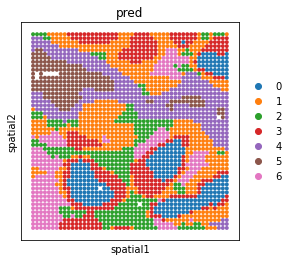

In [5]:
adata_res = sc.AnnData(z)
adata_res.obsm['spatial'] = pos
adata_res.obs['pred'] = pd.Categorical(y_pred)
sc.pl.spatial(adata_res, color='pred', spot_size=1)

Visualize the latent space using UMAP.

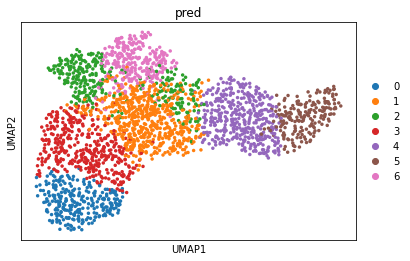

In [ ]:

sc.pp.neighbors(adata_res, n_neighbors=100, use_rep='X', metric='euclidean')

sc.tl.umap(adata_res, min_dist=1)


sc.pl.umap(adata_res, color='pred')